In [2]:
%cd /content
!rm -rf /content/FrameForge
!git clone https://github.com/isakshay007/FrameForge.git
%cd /content/FrameForge


/content
Cloning into 'FrameForge'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 44 (delta 9), reused 40 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 548.95 KiB | 3.21 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/FrameForge


In [3]:
import os, shutil, pandas as pd
from google.colab import files
print("Upload your 2 RDR2 CSV files:")
uploaded = files.upload()
os.makedirs("frameview_logs", exist_ok=True)
!rm -f frameview_logs/*.csv
for filename in uploaded.keys():
    df = pd.read_csv(filename, comment='#', on_bad_lines='skip', nrows=5)
    df.columns = df.columns.str.strip()
    resolution = str(df['Resolution'].iloc[0]).strip()
    if "2560" in resolution:
        new_name = "RDR2_1440p_Ultra_DX12.csv"
    elif "1920" in resolution:
        new_name = "RDR2_1080p_Ultra_DX12.csv"
    else:
        new_name = filename
    shutil.move(filename, f"frameview_logs/{new_name}")
    print(f" {filename} → {new_name} (Resolution: {resolution})")
!ls -la frameview_logs/

Upload your 2 RDR2 CSV files:


Saving FrameView_RDR2.exe_2026_02_26T164138_Log.csv to FrameView_RDR2.exe_2026_02_26T164138_Log.csv
Saving FrameView_RDR2.exe_2026_02_26T164402_Log.csv to FrameView_RDR2.exe_2026_02_26T164402_Log.csv
 FrameView_RDR2.exe_2026_02_26T164138_Log.csv → RDR2_1440p_Ultra_DX12.csv (Resolution: 2560x1440)
 FrameView_RDR2.exe_2026_02_26T164402_Log.csv → RDR2_1080p_Ultra_DX12.csv (Resolution: 1920x1080)
total 10192
drwxr-xr-x 2 root root    4096 Feb 27 04:21 .
drwxr-xr-x 7 root root    4096 Feb 27 04:21 ..
-rw-r--r-- 1 root root       0 Feb 27 04:20 .gitkeep
-rw-r--r-- 1 root root 6463114 Feb 27 04:21 RDR2_1080p_Ultra_DX12.csv
-rw-r--r-- 1 root root 3961467 Feb 27 04:21 RDR2_1440p_Ultra_DX12.csv


In [4]:
!ls -la frameview_logs/

total 10192
drwxr-xr-x 2 root root    4096 Feb 27 04:21 .
drwxr-xr-x 7 root root    4096 Feb 27 04:21 ..
-rw-r--r-- 1 root root       0 Feb 27 04:20 .gitkeep
-rw-r--r-- 1 root root 6463114 Feb 27 04:21 RDR2_1080p_Ultra_DX12.csv
-rw-r--r-- 1 root root 3961467 Feb 27 04:21 RDR2_1440p_Ultra_DX12.csv


In [5]:
import pandas as pd

for csv in ["frameview_logs/RDR2_1080p_Ultra_DX12.csv", "frameview_logs/RDR2_1440p_Ultra_DX12.csv"]:
    print("=" * 60)
    print(f"  {csv.split('/')[-1]}")
    print("=" * 60)
    df = pd.read_csv(csv, comment='#', on_bad_lines='skip')
    df.columns = df.columns.str.strip()

    print(f"\n  Rows: {len(df)} | Columns: {len(df.columns)}\n")

    # Show all columns with their data type, non-null count, and sample values
    for col in df.columns:
        non_null = df[col].notna().sum()
        dtype = df[col].dtype
        sample = df[col].dropna().iloc[0] if non_null > 0 else "ALL NULL"
        pct = non_null / len(df) * 100
        flag = "" if pct > 50 else "" if pct > 0 else ""
        print(f"  {flag} {col:<45} {str(dtype):<10} {pct:>5.1f}% filled   sample: {sample}")

    print(f"\n  First 3 rows of key columns:")
    key_cols = [c for c in ["MsBetweenPresents", "GPU0Clk(MHz)", "GPU0Temp(C)",
                             "GPU0Util(%)", "NV Pwr(W)", "MsPCLatency",
                             "CPUUtil(%)", "Dropped", "Resolution"] if c in df.columns]
    print(df[key_cols].head(3).to_string())
    print()

  RDR2_1080p_Ultra_DX12.csv

  Rows: 12151 | Columns: 112

   Application                                   object     100.0% filled   sample: RDR2.exe
   GPU                                           object     100.0% filled   sample: NVIDIA GeForce RTX 4060 Ti
   CPU                                           object     100.0% filled   sample: 11th Gen Intel(R) Core(TM) i5-11400F @ 2.60GHz
   Resolution                                    object     100.0% filled   sample: 1920x1080
   Runtime                                       object     100.0% filled   sample: D3D12
   AllowsTearing                                 int64      100.0% filled   sample: 0
   ProcessID                                     int64      100.0% filled   sample: 26348
   SwapChainAddress                              object     100.0% filled   sample: 0x000000000314CAB0
   SyncInterval                                  int64      100.0% filled   sample: 1
   PresentFlags                                  int64   

/content/FrameForge
  RDR2 Benchmark — RTX 4060 Ti + i5-11400F — DX12 VSync ON

  [1080P] Frame Performance
  Total Frames: 12151
  Duration: 121.9 seconds

  FPS:
    Average:     101.1
    Median:      99.6
    Max:         231.7
    Min:         33.0
    0.1% Low:    54.9
    1% Low:      79.2
    5% Low:      86.4

  Frame Times:
     50.0%ile:    10.04 ms (99.6 FPS)
     90.0%ile:    11.16 ms (89.6 FPS)
     95.0%ile:    11.58 ms (86.4 FPS)
     99.0%ile:    12.63 ms (79.2 FPS)
     99.9%ile:    18.21 ms (54.9 FPS)
    Std Dev:     1.17 ms (smooth)

  Stutters:
    Mild (>2x avg):  10 (0.08%)
    Hard (>50ms):    0 (0.000%)
    Dropped:         0 (0.00%)

  [1440P] Frame Performance
  Total Frames: 7430
  Duration: 98.3 seconds

  FPS:
    Average:     76.9
    Median:      75.0
    Max:         158.4
    Min:         25.9
    0.1% Low:    41.9
    1% Low:      57.2
    5% Low:      63.5

  Frame Times:
     50.0%ile:    13.33 ms (75.0 FPS)
     90.0%ile:    15.04 ms (66.5 FPS)
  

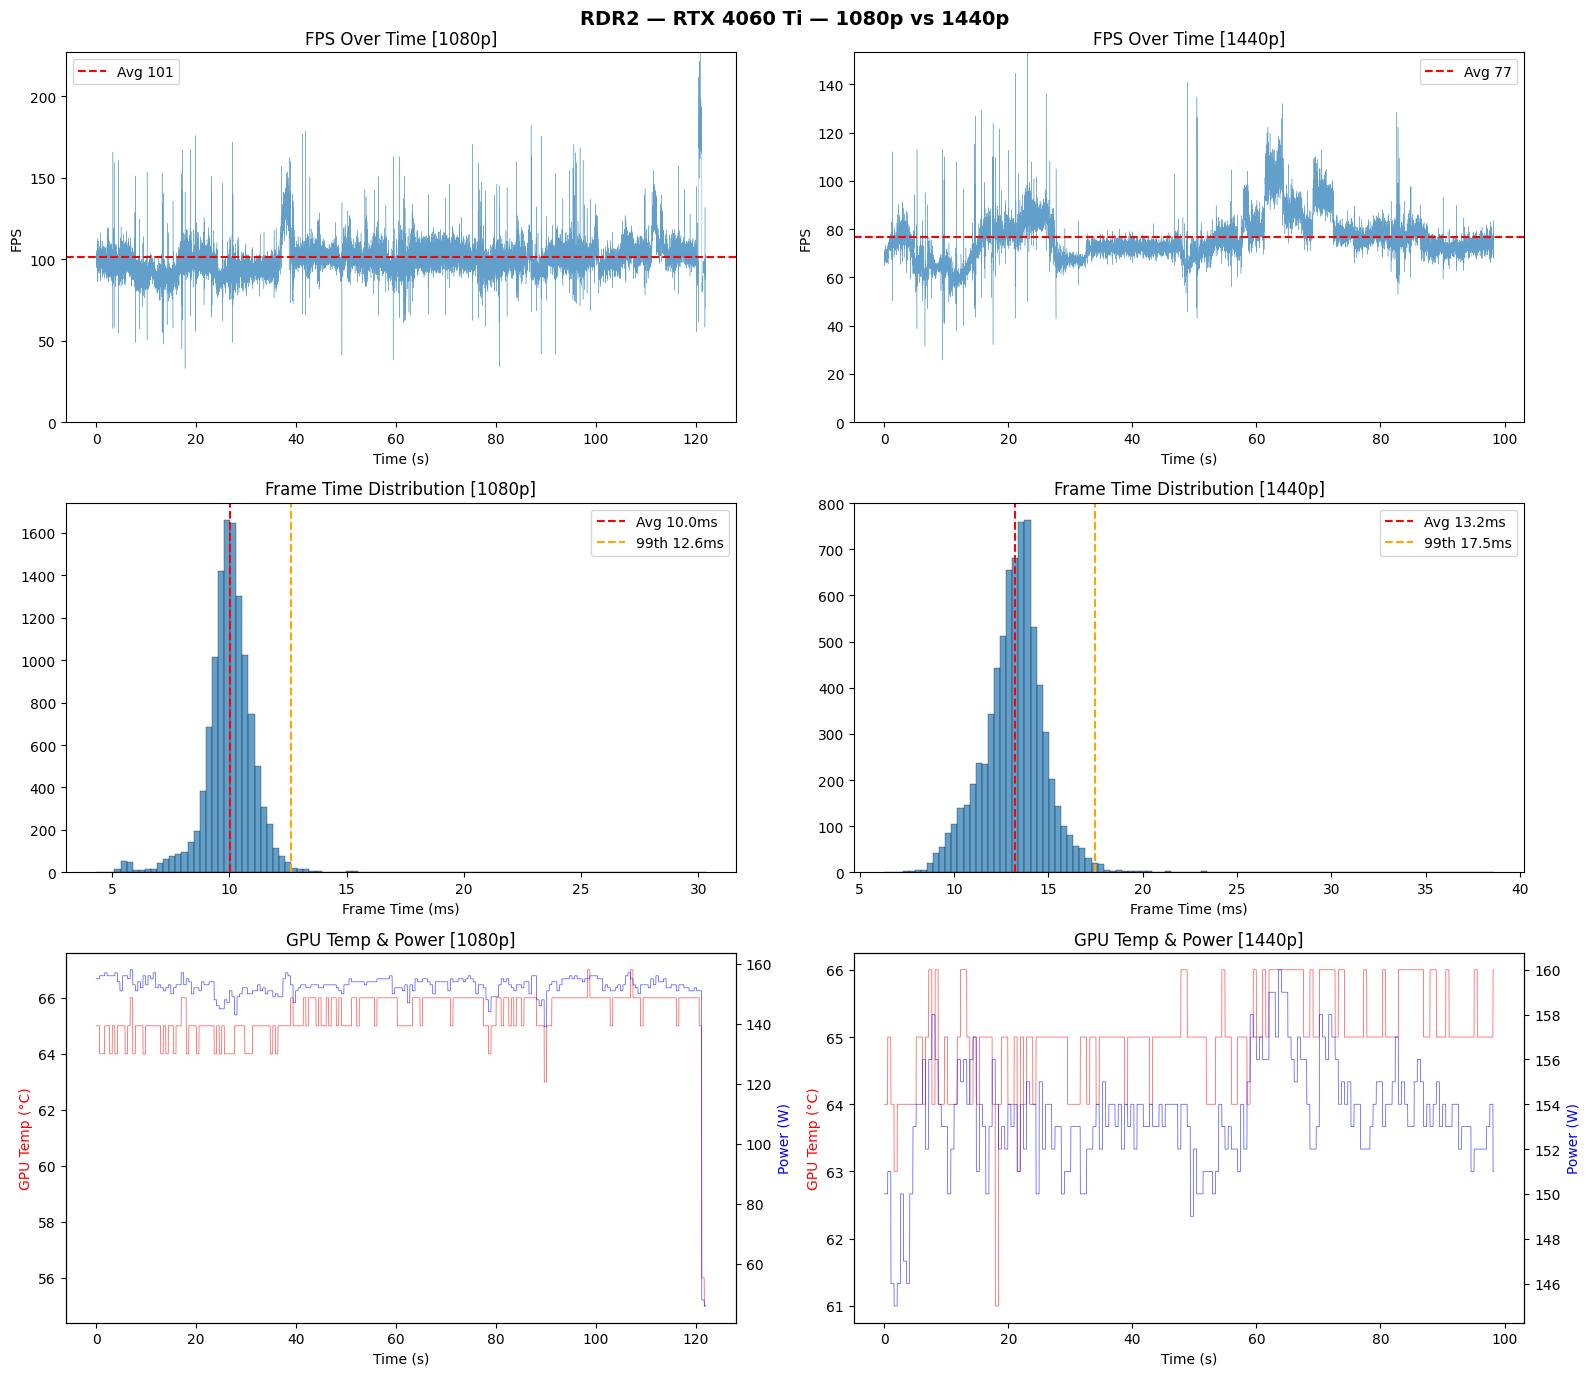


Full analysis complete! Charts saved to results/rdr2_analysis.png


In [7]:
%cd /content/FrameForge
import pandas as pd, numpy as np, matplotlib.pyplot as plt, json

csvs = {
    "1080p": "frameview_logs/RDR2_1080p_Ultra_DX12.csv",
    "1440p": "frameview_logs/RDR2_1440p_Ultra_DX12.csv"
}

data = {}
for label, path in csvs.items():
    df = pd.read_csv(path, comment='#', on_bad_lines='skip')
    df.columns = df.columns.str.strip()
    data[label] = df

print("=" * 70)
print("  RDR2 Benchmark — RTX 4060 Ti + i5-11400F — DX12 VSync ON")
print("=" * 70)

# 1. FRAME TIME & FPS ANALYSIS
for label, df in data.items():
    ft = df["MsBetweenPresents"].dropna()
    fps = 1000 / ft
    print(f"\n{'='*70}")
    print(f"  [{label.upper()}] Frame Performance")
    print(f"{'='*70}")
    print(f"  Total Frames: {len(ft)}")
    print(f"  Duration: {df['TimeInSeconds'].iloc[-1] - df['TimeInSeconds'].iloc[0]:.1f} seconds")

    print(f"\n  FPS:")
    print(f"    Average:     {fps.mean():.1f}")
    print(f"    Median:      {fps.median():.1f}")
    print(f"    Max:         {fps.max():.1f}")
    print(f"    Min:         {fps.min():.1f}")
    print(f"    0.1% Low:    {np.percentile(fps, 0.1):.1f}")
    print(f"    1% Low:      {np.percentile(fps, 1):.1f}")
    print(f"    5% Low:      {np.percentile(fps, 5):.1f}")

    print(f"\n  Frame Times:")
    for p in [50, 90, 95, 99, 99.9]:
        val = np.percentile(ft, p)
        print(f"    {p:>5.1f}%ile:    {val:.2f} ms ({1000/val:.1f} FPS)")
    print(f"    Std Dev:     {ft.std():.2f} ms {'(smooth)' if ft.std() < 3 else '(some jitter)' if ft.std() < 5 else '(unstable)'}")

    # Stutter detection (frames > 2x average)
    avg_ft = ft.mean()
    stutters = (ft > avg_ft * 2).sum()
    hard_stutters = (ft > 50).sum()  # >50ms = below 20fps
    print(f"\n  Stutters:")
    print(f"    Mild (>2x avg):  {stutters} ({stutters/len(ft)*100:.2f}%)")
    print(f"    Hard (>50ms):    {hard_stutters} ({hard_stutters/len(ft)*100:.3f}%)")

    # Dropped frames
    dropped = df["Dropped"].sum()
    print(f"    Dropped:         {int(dropped)} ({dropped/len(df)*100:.2f}%)")

# 2. LATENCY ANALYSIS
print(f"\n{'='*70}")
print(f"  Latency Comparison")
print(f"{'='*70}")
lat_cols = ["MsPCLatency", "MsRenderPresentLatency", "MsUntilDisplayed", "MsInPresentAPI"]
lat_names = ["PC Latency (full)", "Render→Present", "Until Displayed", "In Present API"]
for col, name in zip(lat_cols, lat_names):
    vals = {l: data[l][col].dropna() for l in data}
    print(f"\n  {name}:")
    for l in data:
        v = vals[l]
        print(f"    {l:>5s}: Avg {v.mean():.1f} ms | 99th {np.percentile(v, 99):.1f} ms")

# 3. GPU ANALYSIS
print(f"\n{'='*70}")
print(f"  GPU Analysis")
print(f"{'='*70}")
for label, df in data.items():
    print(f"\n  [{label.upper()}]")
    clk = df["GPU0Clk(MHz)"].dropna()
    print(f"    Clock:  Avg {clk.mean():.0f} MHz | Min {clk.min()} | Max {clk.max()} MHz")
    temp = df["GPU0Temp(C)"].dropna()
    print(f"    Temp:   Avg {temp.mean():.1f}°C | Max {temp.max()}°C {' HOT' if temp.max() > 85 else ' OK'}")
    util = df["GPU0Util(%)"].dropna()
    print(f"    Util:   Avg {util.mean():.1f}% {'(GPU bound)' if util.mean() > 95 else '(CPU limited)' if util.mean() < 80 else ''}")
    pwr = df["NV Pwr(W) (API)"].dropna()
    print(f"    Power:  Avg {pwr.mean():.0f}W | Max {pwr.max()}W")
    gpu_pwr = df["GPUOnlyPwr(W) (API)"].dropna()
    print(f"    GPU-Only Power: Avg {gpu_pwr.mean():.0f}W")
    eff = df["Perf/W GPUOnly(F/J) (API)"].dropna()
    print(f"    Efficiency: {eff.mean():.3f} FPS/W")

# 4. CPU ANALYSIS
print(f"\n{'='*70}")
print(f"  CPU Analysis (i5-11400F — 6C/12T)")
print(f"{'='*70}")
core_cols = [f"CPUCoreUtil%[{i:>2}]" for i in range(12)]
for label, df in data.items():
    print(f"\n  [{label.upper()}]")
    cpu_util = df["CPUUtil(%)"].dropna()
    cpu_clk = df["CPUClk(MHz)"].dropna()
    cpu_temp = df["CPU Package Temp(C)"].dropna()
    cpu_pwr = df["CPU Package Power(W)"].dropna()
    cpu_tdp = df["CPU TDP (W)"].iloc[0]
    print(f"    Util:   Avg {cpu_util.mean():.1f}% | Max {cpu_util.max()}%")
    print(f"    Clock:  Avg {cpu_clk.mean():.0f} MHz | Max {cpu_clk.max()} MHz")
    print(f"    Temp:   Avg {cpu_temp.mean():.1f}°C | Max {cpu_temp.max()}°C {' HOT' if cpu_temp.max() > 90 else ' OK'}")
    print(f"    Power:  Avg {cpu_pwr.mean():.1f}W / {cpu_tdp}W TDP {' OVER TDP' if cpu_pwr.mean() > cpu_tdp else ''}")

    # Per-core utilization
    core_avgs = []
    for c in core_cols:
        if c in df.columns:
            avg = df[c].dropna().mean()
            core_avgs.append(avg)
    if core_avgs:
        print(f"    Per-Core Avg: {', '.join([f'{a:.0f}%' for a in core_avgs])}")
        print(f"    Hottest Core: Core {np.argmax(core_avgs)} ({max(core_avgs):.0f}%)")


# 5. 1080p vs 1440p COMPARISON
print(f"\n{'='*70}")
print(f"  1080p vs 1440p — Impact Summary")
print(f"{'='*70}")
ft_1080 = data["1080p"]["MsBetweenPresents"].dropna()
ft_1440 = data["1440p"]["MsBetweenPresents"].dropna()
fps_1080 = 1000 / ft_1080
fps_1440 = 1000 / ft_1440

metrics = [
    ("Avg FPS",        fps_1080.mean(),        fps_1440.mean()),
    ("1% Low FPS",     np.percentile(fps_1080, 1), np.percentile(fps_1440, 1)),
    ("0.1% Low FPS",   np.percentile(fps_1080, 0.1), np.percentile(fps_1440, 0.1)),
    ("Avg Frame Time", ft_1080.mean(),         ft_1440.mean()),
    ("99th% FT (ms)",  np.percentile(ft_1080, 99), np.percentile(ft_1440, 99)),
    ("FT Std Dev",     ft_1080.std(),          ft_1440.std()),
    ("PC Latency",     data["1080p"]["MsPCLatency"].mean(), data["1440p"]["MsPCLatency"].mean()),
    ("GPU Temp Avg",   data["1080p"]["GPU0Temp(C)"].mean(), data["1440p"]["GPU0Temp(C)"].mean()),
    ("GPU Power Avg",  data["1080p"]["NV Pwr(W) (API)"].mean(), data["1440p"]["NV Pwr(W) (API)"].mean()),
    ("CPU Util Avg",   data["1080p"]["CPUUtil(%)"].mean(), data["1440p"]["CPUUtil(%)"].mean()),
]

for name, v1080, v1440 in metrics:
    if v1080 > 0:
        change = (v1440 - v1080) / v1080 * 100
        arrow = "🔴" if ("FPS" in name and change < -10) or ("FPS" not in name and change > 10) else "🟡" if abs(change) > 5 else "🟢"
        print(f"  {arrow} {name:<20s}  {v1080:>8.1f}  →  {v1440:>8.1f}  ({change:+.1f}%)")

# 6. PLOTS
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("RDR2 — RTX 4060 Ti — 1080p vs 1440p", fontsize=14, fontweight='bold')

# FPS over time
for i, (label, df) in enumerate(data.items()):
    t = df["TimeInSeconds"] - df["TimeInSeconds"].iloc[0]
    fps = 1000 / df["MsBetweenPresents"]
    axes[0, i].plot(t, fps, linewidth=0.3, alpha=0.7)
    axes[0, i].axhline(fps.mean(), color='r', linestyle='--', label=f'Avg {fps.mean():.0f}')
    axes[0, i].set_title(f"FPS Over Time [{label}]")
    axes[0, i].set_ylabel("FPS")
    axes[0, i].set_xlabel("Time (s)")
    axes[0, i].legend()
    axes[0, i].set_ylim(0, fps.quantile(0.999) * 1.2)

# Frame time distribution
for i, (label, df) in enumerate(data.items()):
    ft = df["MsBetweenPresents"]
    axes[1, i].hist(ft, bins=100, alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[1, i].axvline(ft.mean(), color='r', linestyle='--', label=f'Avg {ft.mean():.1f}ms')
    axes[1, i].axvline(np.percentile(ft, 99), color='orange', linestyle='--', label=f'99th {np.percentile(ft, 99):.1f}ms')
    axes[1, i].set_title(f"Frame Time Distribution [{label}]")
    axes[1, i].set_xlabel("Frame Time (ms)")
    axes[1, i].legend()

# GPU Temp + Power over time
for i, (label, df) in enumerate(data.items()):
    t = df["TimeInSeconds"] - df["TimeInSeconds"].iloc[0]
    ax1 = axes[2, i]
    ax1.plot(t, df["GPU0Temp(C)"], color='red', linewidth=0.5, alpha=0.7, label='Temp °C')
    ax1.set_ylabel("GPU Temp (°C)", color='red')
    ax1.set_xlabel("Time (s)")
    ax1.set_title(f"GPU Temp & Power [{label}]")
    ax2 = ax1.twinx()
    ax2.plot(t, df["NV Pwr(W) (API)"], color='blue', linewidth=0.5, alpha=0.7, label='Power W')
    ax2.set_ylabel("Power (W)", color='blue')

plt.tight_layout()
plt.savefig("results/rdr2_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFull analysis complete! Charts saved to results/rdr2_analysis.png")

/content/FrameForge


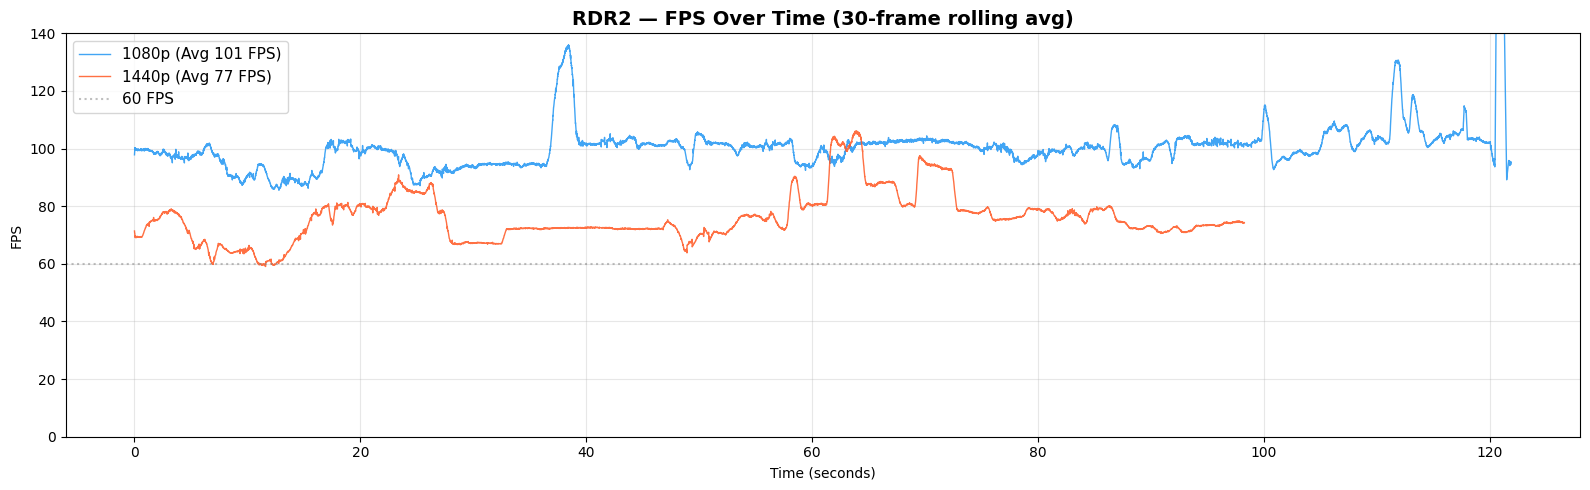

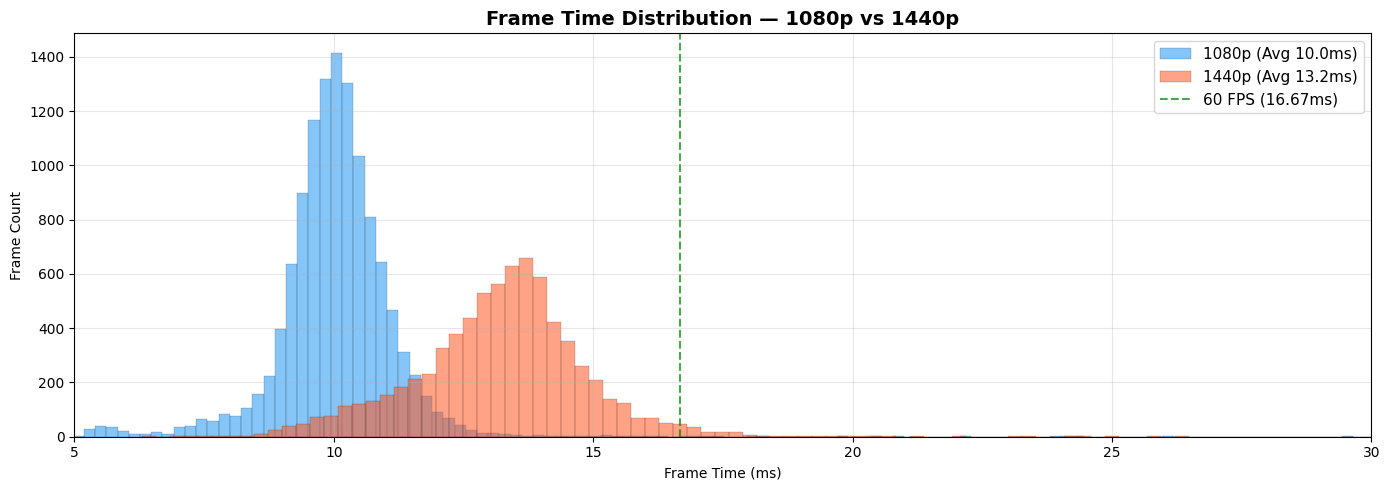

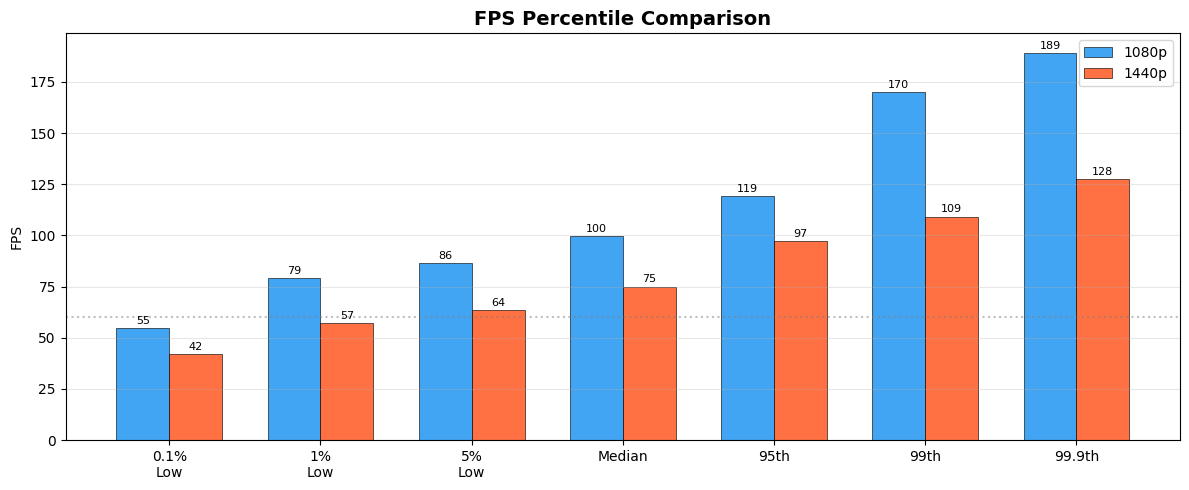

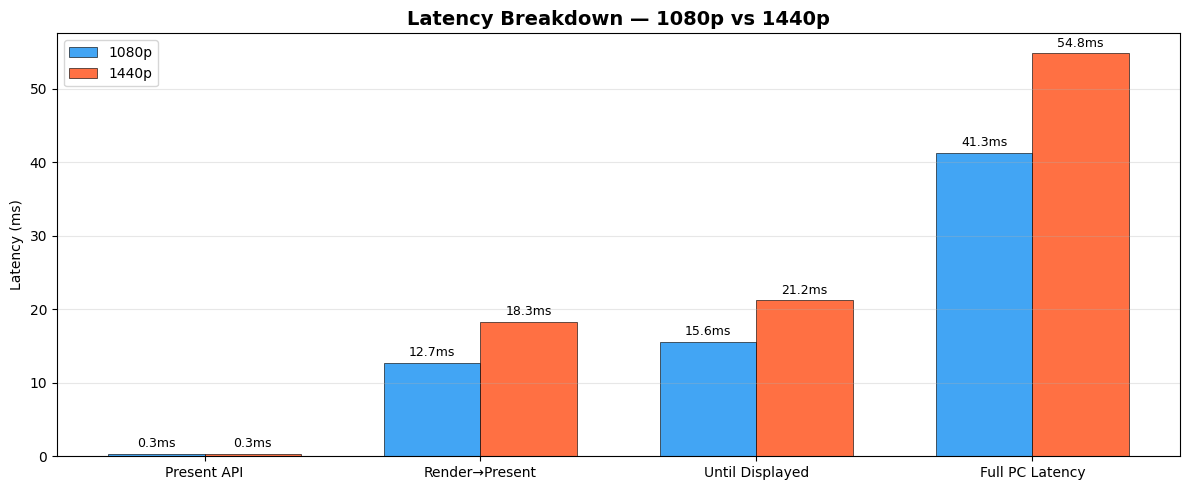

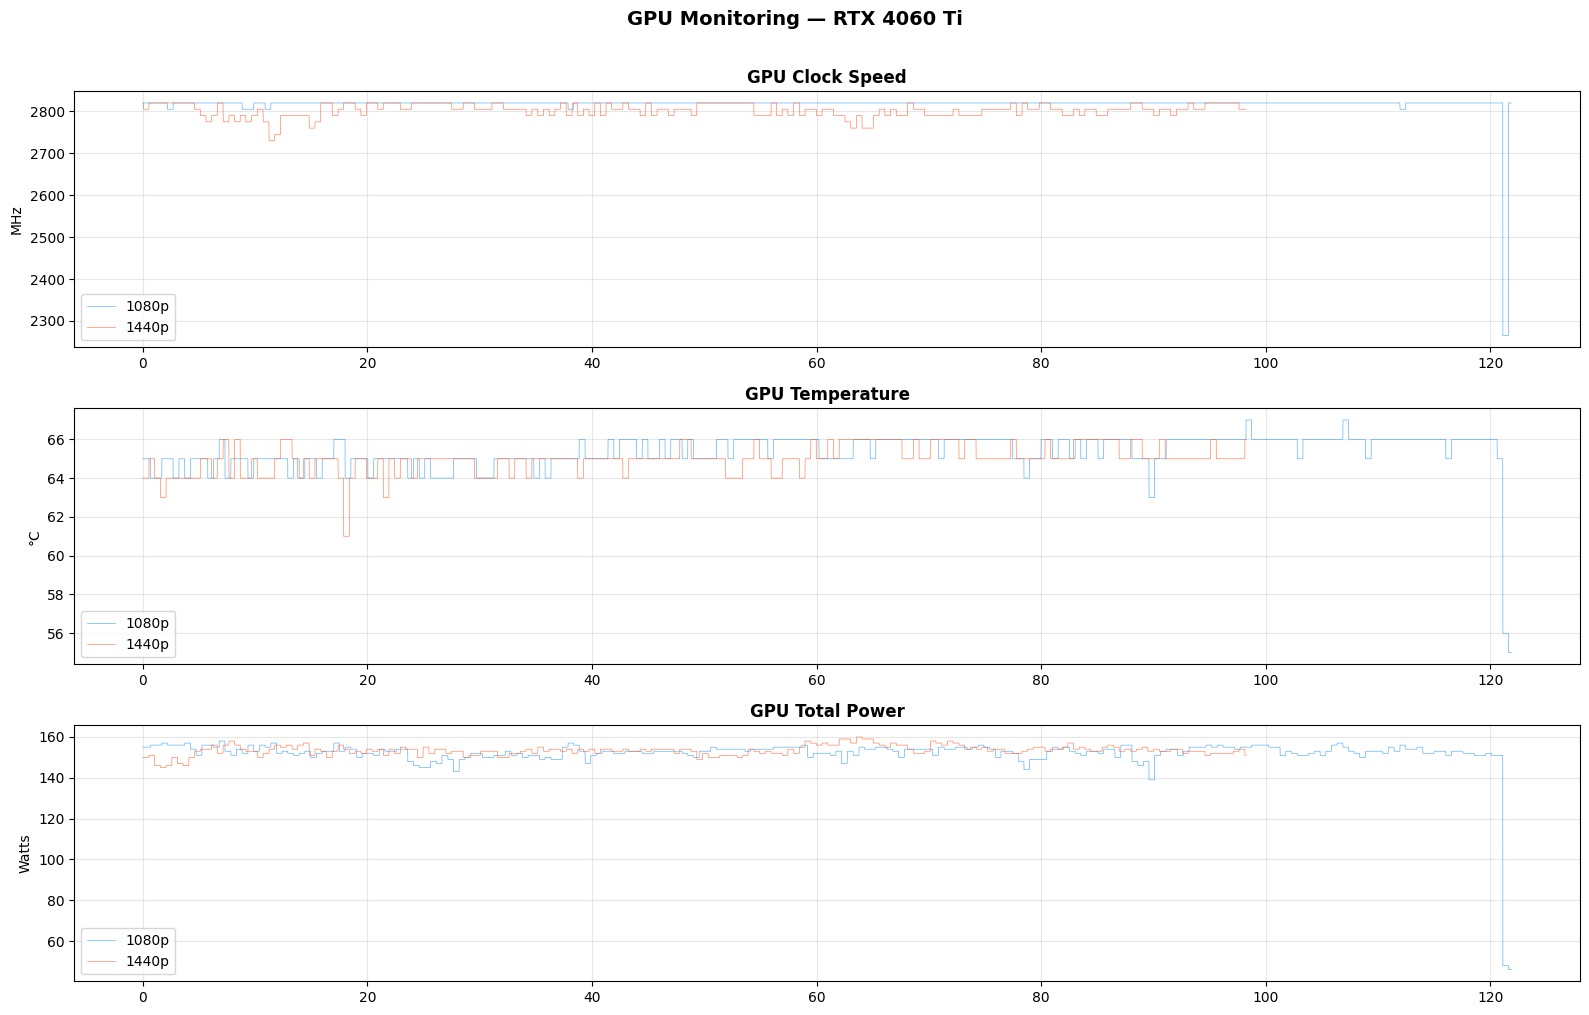

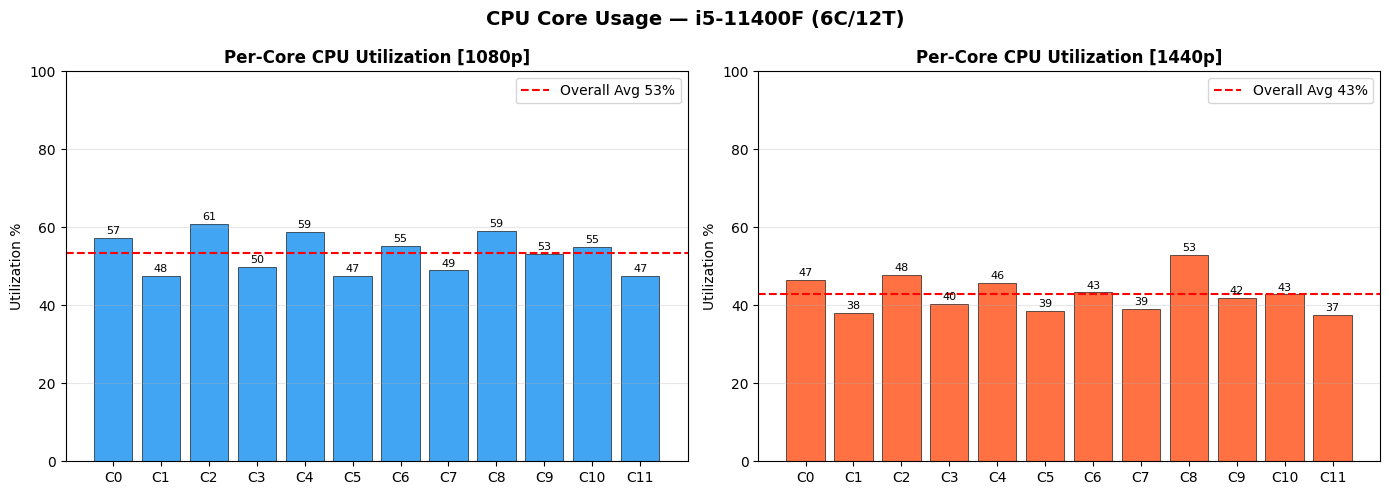

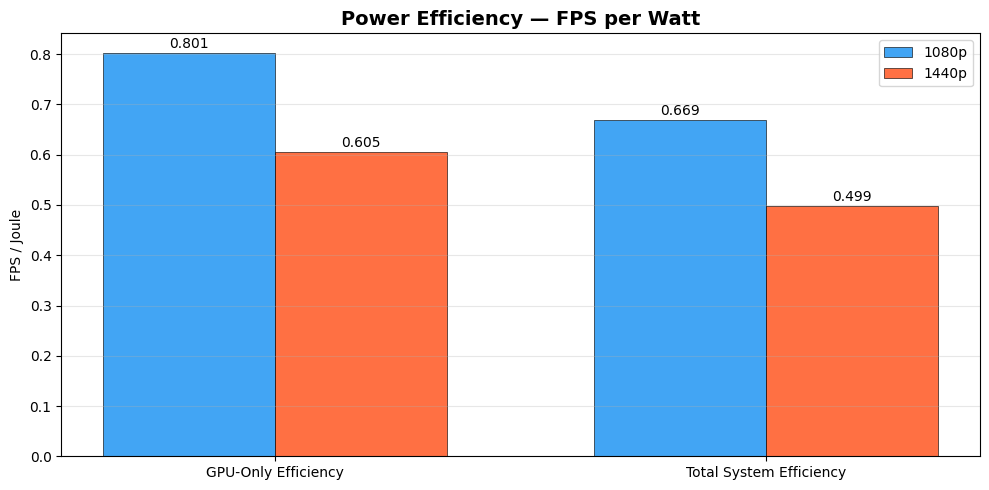

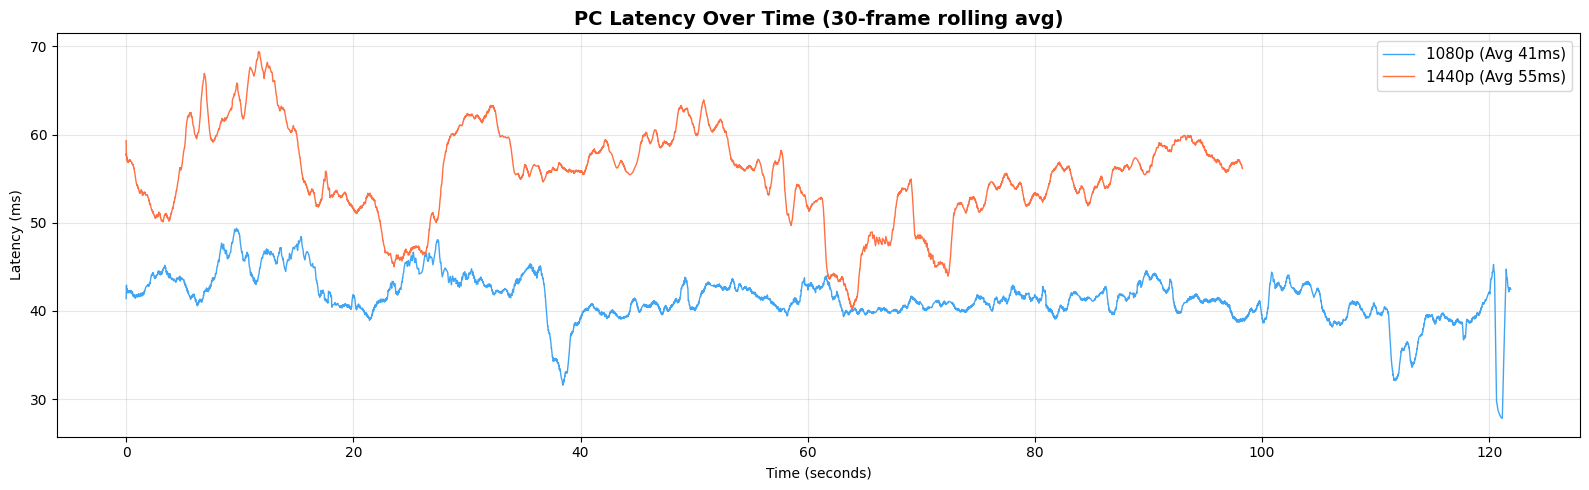


 All 8 charts generated and saved to results/
   01_fps_timeline.png
   02_frametime_dist.png
   03_fps_percentiles.png
   04_latency.png
   05_gpu_monitoring.png
   06_cpu_cores.png
   07_efficiency.png
   08_latency_timeline.png


In [9]:
%cd /content/FrameForge
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import json

# Load data
data = {}
for label, path in [("1080p", "frameview_logs/RDR2_1080p_Ultra_DX12.csv"),
                     ("1440p", "frameview_logs/RDR2_1440p_Ultra_DX12.csv")]:
    df = pd.read_csv(path, comment='#', on_bad_lines='skip')
    df.columns = df.columns.str.strip()
    data[label] = df

colors = {"1080p": "#2196F3", "1440p": "#FF5722"}

# CHART 1: FPS Over Time (Overlay)
fig, ax = plt.subplots(figsize=(16, 5))
for label, df in data.items():
    t = df["TimeInSeconds"] - df["TimeInSeconds"].iloc[0]
    fps = 1000 / df["MsBetweenPresents"]
    # Rolling average for cleaner look
    fps_smooth = fps.rolling(window=30, min_periods=1).mean()
    ax.plot(t, fps_smooth, linewidth=1, alpha=0.85, color=colors[label], label=f'{label} (Avg {fps.mean():.0f} FPS)')
ax.axhline(60, color='gray', linestyle=':', alpha=0.5, label='60 FPS')
ax.set_title("RDR2 — FPS Over Time (30-frame rolling avg)", fontsize=14, fontweight='bold')
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("FPS")
ax.legend(fontsize=11)
ax.set_ylim(0, 140)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/01_fps_timeline.png", dpi=150)
plt.show()

# CHART 2: Frame Time Distribution (Overlay)
fig, ax = plt.subplots(figsize=(14, 5))
for label, df in data.items():
    ft = df["MsBetweenPresents"]
    ax.hist(ft, bins=120, alpha=0.55, color=colors[label], label=f'{label} (Avg {ft.mean():.1f}ms)', edgecolor='black', linewidth=0.2)
ax.axvline(16.67, color='green', linestyle='--', alpha=0.7, label='60 FPS (16.67ms)')
ax.set_title("Frame Time Distribution — 1080p vs 1440p", fontsize=14, fontweight='bold')
ax.set_xlabel("Frame Time (ms)")
ax.set_ylabel("Frame Count")
ax.set_xlim(5, 30)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/02_frametime_dist.png", dpi=150)
plt.show()

# CHART 3: FPS Percentile Comparison
fig, ax = plt.subplots(figsize=(12, 5))
percentiles = [0.1, 1, 5, 50, 95, 99, 99.9]
pct_labels = ["0.1%\nLow", "1%\nLow", "5%\nLow", "Median", "95th", "99th", "99.9th"]
x = np.arange(len(percentiles))
width = 0.35
for i, (label, df) in enumerate(data.items()):
    fps = 1000 / df["MsBetweenPresents"]
    vals = [np.percentile(fps, 100-p) if p < 50 else np.percentile(fps, 100-p) for p in percentiles]
    vals = [np.percentile(fps, p) for p in percentiles]
    bars = ax.bar(x + (i * width), vals, width, label=label, color=colors[label], alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width/2)
ax.set_xticklabels(pct_labels)
ax.set_title("FPS Percentile Comparison", fontsize=14, fontweight='bold')
ax.set_ylabel("FPS")
ax.legend()
ax.axhline(60, color='gray', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("results/03_fps_percentiles.png", dpi=150)
plt.show()

# CHART 4: Latency Breakdown
fig, ax = plt.subplots(figsize=(12, 5))
lat_cols = ["MsInPresentAPI", "MsRenderPresentLatency", "MsUntilDisplayed", "MsPCLatency"]
lat_names = ["Present API", "Render→Present", "Until Displayed", "Full PC Latency"]
x = np.arange(len(lat_names))
width = 0.35
for i, (label, df) in enumerate(data.items()):
    vals = [df[c].mean() for c in lat_cols]
    bars = ax.bar(x + (i * width), vals, width, label=label, color=colors[label], alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}ms', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x + width/2)
ax.set_xticklabels(lat_names)
ax.set_title("Latency Breakdown — 1080p vs 1440p", fontsize=14, fontweight='bold')
ax.set_ylabel("Latency (ms)")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("results/04_latency.png", dpi=150)
plt.show()

# CHART 5: GPU Clocks, Temp & Power Over Time
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)
for label, df in data.items():
    t = df["TimeInSeconds"] - df["TimeInSeconds"].iloc[0]
    c = colors[label]
    axes[0].plot(t, df["GPU0Clk(MHz)"], linewidth=0.5, alpha=0.7, color=c, label=label)
    axes[1].plot(t, df["GPU0Temp(C)"], linewidth=0.5, alpha=0.7, color=c, label=label)
    axes[2].plot(t, df["NV Pwr(W) (API)"], linewidth=0.5, alpha=0.7, color=c, label=label)
axes[0].set_title("GPU Clock Speed", fontweight='bold')
axes[0].set_ylabel("MHz")
axes[1].set_title("GPU Temperature", fontweight='bold')
axes[1].set_ylabel("°C")
axes[2].set_title("GPU Total Power", fontweight='bold')
axes[2].set_ylabel("Watts")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("GPU Monitoring — RTX 4060 Ti", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("results/05_gpu_monitoring.png", dpi=150)
plt.show()

# CHART 6: CPU Utilization + Per-Core Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
core_cols = [f"CPUCoreUtil%[{i:>2}]" for i in range(12)]
core_labels = [f"C{i}" for i in range(12)]
for i, (label, df) in enumerate(data.items()):
    core_avgs = [df[c].mean() for c in core_cols]
    bars = axes[i].bar(core_labels, core_avgs, color=colors[label], alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[i].axhline(df["CPUUtil(%)"].mean(), color='red', linestyle='--', label=f'Overall Avg {df["CPUUtil(%)"].mean():.0f}%')
    axes[i].set_title(f"Per-Core CPU Utilization [{label}]", fontweight='bold')
    axes[i].set_ylabel("Utilization %")
    axes[i].set_ylim(0, 100)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, core_avgs):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}', ha='center', fontsize=8)
plt.suptitle("CPU Core Usage — i5-11400F (6C/12T)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("results/06_cpu_cores.png", dpi=150)
plt.show()

# CHART 7: Efficiency (Perf/Watt)
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["Perf/W GPUOnly(F/J) (API)", "Perf/W Total(F/J) (API)"]
metric_names = ["GPU-Only Efficiency", "Total System Efficiency"]
x = np.arange(len(metric_names))
width = 0.35
for i, (label, df) in enumerate(data.items()):
    vals = [df[m].mean() for m in metrics]
    bars = ax.bar(x + (i * width), vals, width, label=label, color=colors[label], alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)
ax.set_xticks(x + width/2)
ax.set_xticklabels(metric_names)
ax.set_title("Power Efficiency — FPS per Watt", fontsize=14, fontweight='bold')
ax.set_ylabel("FPS / Joule")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("results/07_efficiency.png", dpi=150)
plt.show()

# CHART 8: PC Latency Over Time
fig, ax = plt.subplots(figsize=(16, 5))
for label, df in data.items():
    t = df["TimeInSeconds"] - df["TimeInSeconds"].iloc[0]
    lat_smooth = df["MsPCLatency"].rolling(window=30, min_periods=1).mean()
    ax.plot(t, lat_smooth, linewidth=1, alpha=0.85, color=colors[label], label=f'{label} (Avg {df["MsPCLatency"].mean():.0f}ms)')
ax.set_title("PC Latency Over Time (30-frame rolling avg)", fontsize=14, fontweight='bold')
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Latency (ms)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/08_latency_timeline.png", dpi=150)
plt.show()

print("\n All 8 charts generated and saved to results/")
print("   01_fps_timeline.png")
print("   02_frametime_dist.png")
print("   03_fps_percentiles.png")
print("   04_latency.png")
print("   05_gpu_monitoring.png")
print("   06_cpu_cores.png")
print("   07_efficiency.png")
print("   08_latency_timeline.png")

In [10]:
!pip install -q openai

In [16]:
%cd /content/FrameForge
import os, json, pandas as pd, numpy as np
from openai import OpenAI

# === YOUR NVIDIA NIM API KEY ===
NVIDIA_API_KEY = "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"

client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=NVIDIA_API_KEY
)

# Load raw CSV data
data = {}
for label, path in [("1080p", "frameview_logs/RDR2_1080p_Ultra_DX12.csv"),
                     ("1440p", "frameview_logs/RDR2_1440p_Ultra_DX12.csv")]:
    df = pd.read_csv(path, comment='#', on_bad_lines='skip')
    df.columns = df.columns.str.strip()
    data[label] = df

# Build comprehensive stats from every useful column
def deep_stats(df, label):
    ft = df["MsBetweenPresents"].dropna()
    fps = 1000 / ft
    sim = df["MsBetweenSimulationStart"].dropna()
    display = df["MsBetweenDisplayChange"].dropna()
    api = df["MsInPresentAPI"].dropna()
    render = df["MsRenderPresentLatency"].dropna()
    until_disp = df["MsUntilDisplayed"].dropna()
    pc_lat = df["MsPCLatency"].dropna()
    queue = df["Render Queue Depth"].dropna()
    gpu_clk = df["GPU0Clk(MHz)"].dropna()
    gpu_mem = df["GPU0MemClk(MHz)"].dropna()
    gpu_util = df["GPU0Util(%)"].dropna()
    gpu_temp = df["GPU0Temp(C)"].dropna()
    gpu_pwr = df["NV Pwr(W) (API)"].dropna()
    gpu_only = df["GPUOnlyPwr(W) (API)"].dropna()
    eff_gpu = df["Perf/W GPUOnly(F/J) (API)"].dropna()
    eff_total = df["Perf/W Total(F/J) (API)"].dropna()
    cpu_clk = df["CPUClk(MHz)"].dropna()
    cpu_util = df["CPUUtil(%)"].dropna()
    cpu_temp = df["CPU Package Temp(C)"].dropna()
    cpu_pwr = df["CPU Package Power(W)"].dropna()
    cpu_tdp = df["CPU TDP (W)"].iloc[0]
    dropped = df["Dropped"].sum()
    duration = df['TimeInSeconds'].iloc[-1] - df['TimeInSeconds'].iloc[0]

    # Frame time buckets for distribution analysis
    buckets = {
        "<8ms (>125fps)": (ft < 8).sum(),
        "8-10ms (100-125fps)": ((ft >= 8) & (ft < 10)).sum(),
        "10-13ms (77-100fps)": ((ft >= 10) & (ft < 13)).sum(),
        "13-16.7ms (60-77fps)": ((ft >= 13) & (ft < 16.67)).sum(),
        "16.7-20ms (50-60fps)": ((ft >= 16.67) & (ft < 20)).sum(),
        "20-33ms (30-50fps)": ((ft >= 20) & (ft < 33)).sum(),
        ">33ms (<30fps)": (ft >= 33).sum(),
    }

    # Stutter classification
    mild_stutters = (ft > ft.mean() * 2).sum()
    moderate_stutters = (ft > ft.mean() * 3).sum()
    hard_stutters = (ft > 50).sum()

    # Frame time stability windows (check for degradation over time)
    n = len(ft)
    q1_avg = ft.iloc[:n//4].mean()
    q2_avg = ft.iloc[n//4:n//2].mean()
    q3_avg = ft.iloc[n//2:3*n//4].mean()
    q4_avg = ft.iloc[3*n//4:].mean()

    # Per-core CPU utilization
    core_cols = [f"CPUCoreUtil%[{i:>2}]" for i in range(12)]
    core_data = ", ".join([f"Core{i}: {df[c].mean():.0f}% (max {df[c].max()}%)" for i, c in enumerate(core_cols)])

    # Clock stability check
    clk_drops = (gpu_clk < gpu_clk.max() * 0.95).sum()
    clk_drop_pct = clk_drops / len(gpu_clk) * 100

    return f"""
{'='*50}
[{label.upper()}] {df['Resolution'].iloc[0]} — {df['Application'].iloc[0]}
{'='*50}

FRAME PERFORMANCE:
  Total Frames: {len(ft)} | Duration: {duration:.1f}s | Avg Framerate: {len(ft)/duration:.1f} fps
  FPS: Avg {fps.mean():.2f} | Median {fps.median():.2f} | Min {fps.min():.2f} | Max {fps.max():.2f}
  FPS Percentiles:
    0.1% Low: {np.percentile(fps, 0.1):.2f} | 1% Low: {np.percentile(fps, 1):.2f} | 5% Low: {np.percentile(fps, 5):.2f}
    95th: {np.percentile(fps, 95):.2f} | 99th: {np.percentile(fps, 99):.2f} | 99.9th: {np.percentile(fps, 99.9):.2f}
  Frame Time: Avg {ft.mean():.3f}ms | Median {ft.median():.3f}ms
  Frame Time Percentiles:
    1st: {np.percentile(ft, 1):.3f}ms | 5th: {np.percentile(ft, 5):.3f}ms | 10th: {np.percentile(ft, 10):.3f}ms
    25th: {np.percentile(ft, 25):.3f}ms | 50th: {np.percentile(ft, 50):.3f}ms | 75th: {np.percentile(ft, 75):.3f}ms
    90th: {np.percentile(ft, 90):.3f}ms | 95th: {np.percentile(ft, 95):.3f}ms | 99th: {np.percentile(ft, 99):.3f}ms
    99.9th: {np.percentile(ft, 99.9):.3f}ms | Max: {ft.max():.3f}ms
  StdDev: {ft.std():.3f}ms | Variance Coefficient: {ft.std()/ft.mean():.4f}
  IQR (25th-75th): {np.percentile(ft, 75) - np.percentile(ft, 25):.3f}ms

FRAME TIME DISTRIBUTION:
  {chr(10).join([f'  {k}: {v} frames ({v/len(ft)*100:.1f}%)' for k, v in buckets.items()])}

FRAME PACING (simulation vs present vs display):
  MsBetweenSimulationStart: Avg {sim.mean():.3f}ms | StdDev {sim.std():.3f}ms
  MsBetweenPresents:        Avg {ft.mean():.3f}ms | StdDev {ft.std():.3f}ms
  MsBetweenDisplayChange:   Avg {display.mean():.3f}ms | StdDev {display.std():.3f}ms
  Sim-to-Present Delta:     {abs(sim.mean() - ft.mean()):.3f}ms avg difference
  Present-to-Display Delta: {abs(ft.mean() - display.mean()):.3f}ms avg difference

STUTTER ANALYSIS:
  Mild (>2x avg frame time):     {mild_stutters} ({mild_stutters/len(ft)*100:.3f}%)
  Moderate (>3x avg frame time): {moderate_stutters} ({moderate_stutters/len(ft)*100:.3f}%)
  Hard (>50ms):                  {hard_stutters} ({hard_stutters/len(ft)*100:.4f}%)
  Dropped Frames:                {int(dropped)} ({dropped/len(df)*100:.3f}%)
  Smoothness Ratio (P99/Median): {np.percentile(ft, 99) / ft.median():.3f}

FRAME TIME STABILITY OVER SESSION:
  Quarter 1 (0-25%):   Avg {q1_avg:.3f}ms ({1000/q1_avg:.1f} FPS)
  Quarter 2 (25-50%):  Avg {q2_avg:.3f}ms ({1000/q2_avg:.1f} FPS)
  Quarter 3 (50-75%):  Avg {q3_avg:.3f}ms ({1000/q3_avg:.1f} FPS)
  Quarter 4 (75-100%): Avg {q4_avg:.3f}ms ({1000/q4_avg:.1f} FPS)
  Session Drift: {((q4_avg - q1_avg) / q1_avg * 100):+.2f}% (positive = degrading)

LATENCY PIPELINE:
  MsInPresentAPI:          Avg {api.mean():.3f}ms | 99th {np.percentile(api, 99):.3f}ms (driver overhead)
  MsRenderPresentLatency:  Avg {render.mean():.3f}ms | 99th {np.percentile(render, 99):.3f}ms (GPU render time)
  MsUntilDisplayed:        Avg {until_disp.mean():.3f}ms | 99th {np.percentile(until_disp, 99):.3f}ms (scanout delay)
  MsPCLatency:             Avg {pc_lat.mean():.3f}ms | 99th {np.percentile(pc_lat, 99):.3f}ms (full input-to-photon)
  Render Queue Depth:      Avg {queue.mean():.3f} | Max {queue.max():.3f} (>2 = queuing delay)
  VSync: {'ON' if df['SyncInterval'].iloc[0] == 1 else 'OFF'} (SyncInterval={df['SyncInterval'].iloc[0]})
  PresentMode: {df['PresentMode'].iloc[0]}

GPU PERFORMANCE:
  Model: {df['GPU'].iloc[0]}
  Core Clock:  Avg {gpu_clk.mean():.0f} MHz | Min {gpu_clk.min()} MHz | Max {gpu_clk.max()} MHz
  Clock Drops (>5% below max): {clk_drops} samples ({clk_drop_pct:.1f}%) — {'THROTTLING DETECTED' if clk_drop_pct > 5 else 'stable'}
  Memory Clock: Avg {gpu_mem.mean():.0f} MHz | Min {gpu_mem.min()} MHz | Max {gpu_mem.max()} MHz
  Utilization: Avg {gpu_util.mean():.1f}% | Min {gpu_util.min()}% | Max {gpu_util.max()}%
  Temperature: Avg {gpu_temp.mean():.1f}°C | Min {gpu_temp.min()}°C | Max {gpu_temp.max()}°C
  Total Power: Avg {gpu_pwr.mean():.1f}W | Min {gpu_pwr.min()}W | Max {gpu_pwr.max()}W
  GPU-Only Power: Avg {gpu_only.mean():.1f}W | Min {gpu_only.min()}W | Max {gpu_only.max()}W
  Efficiency (GPU-Only): {eff_gpu.mean():.4f} FPS/Watt
  Efficiency (Total):    {eff_total.mean():.4f} FPS/Watt

CPU PERFORMANCE:
  Model: {df['CPU'].iloc[0]}
  Clock: Avg {cpu_clk.mean():.0f} MHz | Min {cpu_clk.min()} MHz | Max {cpu_clk.max()} MHz
  Utilization: Avg {cpu_util.mean():.1f}% | Min {cpu_util.min()}% | Max {cpu_util.max()}%
  Temperature: Avg {cpu_temp.mean():.1f}°C | Min {cpu_temp.min()}°C | Max {cpu_temp.max()}°C
  Power: Avg {cpu_pwr.mean():.1f}W | Min {cpu_pwr.min():.1f}W | Max {cpu_pwr.max():.1f}W
  TDP: {cpu_tdp}W | Over TDP: {'YES — avg {:.1f}W over'.format(cpu_pwr.mean() - cpu_tdp) if cpu_pwr.mean() > cpu_tdp else 'NO'}
  Per-Core Utilization (12 threads):
    {core_data}
"""

stats_1080 = deep_stats(data["1080p"], "1080p")
stats_1440 = deep_stats(data["1440p"], "1440p")

# Resolution scaling comparison
ft_1080 = data["1080p"]["MsBetweenPresents"].mean()
ft_1440 = data["1440p"]["MsBetweenPresents"].mean()
fps_1080 = 1000 / ft_1080
fps_1440 = 1000 / ft_1440

scaling = f"""
{'='*50}
RESOLUTION SCALING: 1080p → 1440p
{'='*50}
  Pixel Count: {1920*1080:,} → {2560*1440:,} ({((2560*1440)/(1920*1080) - 1)*100:.1f}% increase)
  FPS: {fps_1080:.1f} → {fps_1440:.1f} ({((fps_1440/fps_1080) - 1)*100:.1f}%)
  Frame Time: {ft_1080:.2f}ms → {ft_1440:.2f}ms ({((ft_1440/ft_1080) - 1)*100:.1f}%)
  1% Low FPS: {np.percentile(1000/data["1080p"]["MsBetweenPresents"], 1):.1f} → {np.percentile(1000/data["1440p"]["MsBetweenPresents"], 1):.1f}
  PC Latency: {data["1080p"]["MsPCLatency"].mean():.1f}ms → {data["1440p"]["MsPCLatency"].mean():.1f}ms ({((data["1440p"]["MsPCLatency"].mean()/data["1080p"]["MsPCLatency"].mean()) - 1)*100:.1f}%)
  GPU Power: {data["1080p"]["NV Pwr(W) (API)"].mean():.1f}W → {data["1440p"]["NV Pwr(W) (API)"].mean():.1f}W
  GPU Temp: {data["1080p"]["GPU0Temp(C)"].mean():.1f}°C → {data["1440p"]["GPU0Temp(C)"].mean():.1f}°C
  CPU Util: {data["1080p"]["CPUUtil(%)"].mean():.1f}% → {data["1440p"]["CPUUtil(%)"].mean():.1f}% ({((data["1440p"]["CPUUtil(%)"].mean()/data["1080p"]["CPUUtil(%)"].mean()) - 1)*100:.1f}%)
  Efficiency: {data["1080p"]["Perf/W GPUOnly(F/J) (API)"].mean():.4f} → {data["1440p"]["Perf/W GPUOnly(F/J) (API)"].mean():.4f} FPS/W ({((data["1440p"]["Perf/W GPUOnly(F/J) (API)"].mean()/data["1080p"]["Perf/W GPUOnly(F/J) (API)"].mean()) - 1)*100:.1f}%)
  Stutter Rate: {(data["1080p"]["MsBetweenPresents"] > data["1080p"]["MsBetweenPresents"].mean()*2).mean()*100:.3f}% → {(data["1440p"]["MsBetweenPresents"] > data["1440p"]["MsBetweenPresents"].mean()*2).mean()*100:.3f}%
"""

prompt = f"""You are an elite NVIDIA GPU performance engineer with 15+ years of experience in game optimization, GPU architecture, and frame analysis. You have deep expertise in NVIDIA Ada Lovelace architecture, DirectX 12 frame pipeline, and FrameView telemetry.

Analyze this REAL FrameView benchmark data captured from an actual gaming PC running Red Dead Redemption 2 at Ultra settings.

{stats_1080}
{stats_1440}
{scaling}

Based on ALL the data above, provide an EXHAUSTIVE technical analysis. Do NOT give generic advice — reference the SPECIFIC numbers from the data.

1. BOTTLENECK IDENTIFICATION
   - Is the system GPU-bound or CPU-bound at each resolution? Cite exact utilization numbers.
   - Per-core CPU analysis — is any single core maxed out causing a thread bottleneck?
   - Render queue depth interpretation — is the driver pre-rendering too many frames?
   - At 1080p, CPU util is higher — explain why and whether this indicates a partial CPU limit.

2. THERMAL & POWER DEEP DIVE
   - GPU clock stability analysis — are the clock drops indicating thermal throttling?
   - CPU running over TDP — what are the consequences? Is PL2 boost behavior normal here?
   - Power efficiency comparison — why does 1440p use similar power but deliver fewer frames?
   - Is the cooling solution adequate based on max temps?

3. LATENCY PIPELINE BREAKDOWN
   - Break down the FULL latency chain: Present API → Render → Display → PC Latency
   - Where is the biggest latency contributor at each resolution?
   - VSync ON with SyncInterval=1 — quantify the exact latency penalty in ms
   - Would NVIDIA Reflex reduce latency? By approximately how much?
   - Is the render queue depth contributing to latency?

4. FRAME PACING & SMOOTHNESS DEEP ANALYSIS
   - Compare simulation time vs present time vs display change — are they in sync?
   - Frame time distribution shape — is it gaussian, skewed, or bimodal?
   - Session stability — does performance degrade over the session? (check quarter data)
   - IQR analysis — how tight is the middle 50% of frame times?
   - Are the mild stutters concerning or within normal bounds for RDR2?

5. RESOLUTION SCALING ANALYSIS
   - Pixel count increases 78% — does the actual FPS drop match expectations?
   - Is the RTX 4060 Ti memory bandwidth (288 GB/s) sufficient for 1440p Ultra?
   - Why does CPU utilization DROP at 1440p? Explain the GPU-bottleneck effect.
   - Efficiency loss at 1440p — is this normal for Ada Lovelace architecture?

6. TOP 5 RDR2 OPTIMIZATION RECOMMENDATIONS
   - List SPECIFIC RDR2 graphics settings to change (not generic advice)
   - For each setting, estimate the FPS gain at 1440p
   - Rank by visual impact vs FPS gain tradeoff

7. DLSS / FSR ANALYSIS
   - Would DLSS Quality at 1440p help? Estimate the output resolution and expected FPS
   - DLSS Balanced vs Quality — which is better for this scenario?
   - Would FSR 3 frame generation be beneficial?
   - Any concerns about DLSS artifacts in RDR2 specifically?

8. GAMING EXPERIENCE VERDICT
   - Rate 1080p experience (Excellent/Good/Playable/Poor) with justification
   - Rate 1440p experience with justification
   - Which resolution is the sweet spot for this hardware?
   - Is VSync helping or hurting the experience?

9. HARDWARE UPGRADE RECOMMENDATIONS
   - Single most impactful upgrade for this specific system
   - Is the i5-11400F bottlenecking the RTX 4060 Ti at 1080p?
   - Would more RAM, faster RAM, or an SSD make any difference?
   - If budget allows one GPU upgrade, which card gives the best value at 1440p?"""

print("=" * 70)
print("  Sending COMPREHENSIVE benchmark data to DeepSeek R1 via NVIDIA NIM")
print("  Data includes: frame times, percentiles, distribution, pacing,")
print("  latency pipeline, GPU/CPU clocks/temp/power, per-core CPU,")
print("  session stability, resolution scaling, and efficiency metrics")
print("  (This may take 60-120 seconds — R1 reasons deeply)")
print("=" * 70)

response = client.chat.completions.create(
    model="deepseek-ai/deepseek-v3.2",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.6,
    top_p=0.7,
    max_tokens=4096,
    stream=False
)

# Extract reasoning and final answer
reasoning = getattr(response.choices[0].message, "reasoning_content", None)
analysis = response.choices[0].message.content

# Print full report
print("\n" + "=" * 70)
print("  FrameForge AI Performance Report — COMPREHENSIVE EDITION")
print("  Powered by DeepSeek R1 via NVIDIA NIM")
print("  System: RTX 4060 Ti + i5-11400F | Game: RDR2 Ultra DX12")
print("=" * 70)

if reasoning:
    print("\n" + "-" * 70)
    print("  DeepSeek R1 — Internal Reasoning Process")
    print("-" * 70)
    # Print first 3000 chars of reasoning
    print(reasoning[:3000] + "\n  [...truncated, full version saved to file]" if len(reasoning) > 3000 else reasoning)
    print("-" * 70)

print("\n" + analysis)

# Save everything
os.makedirs("results", exist_ok=True)
with open("results/ai_advisor_report.txt", "w") as f:
    f.write("=" * 70 + "\n")
    f.write("  FrameForge AI Performance Report — COMPREHENSIVE EDITION\n")
    f.write("  Powered by DeepSeek R1 via NVIDIA NIM\n")
    f.write("  System: RTX 4060 Ti + i5-11400F\n")
    f.write("  Game: Red Dead Redemption 2 — Ultra — DX12\n")
    f.write("=" * 70 + "\n\n")
    f.write(analysis)

if reasoning:
    with open("results/ai_advisor_reasoning.txt", "w") as f:
        f.write("=" * 70 + "\n")
        f.write("  DeepSeek R1 — Full Internal Reasoning Chain\n")
        f.write("  (Shows exactly how R1 analyzed your benchmark data)\n")
        f.write("=" * 70 + "\n\n")
        f.write(reasoning)
    print("\n R1 reasoning chain saved to results/ai_advisor_reasoning.txt")

print(" Full AI report saved to results/ai_advisor_report.txt")

/content/FrameForge
  Sending COMPREHENSIVE benchmark data to DeepSeek R1 via NVIDIA NIM
  Data includes: frame times, percentiles, distribution, pacing,
  latency pipeline, GPU/CPU clocks/temp/power, per-core CPU,
  session stability, resolution scaling, and efficiency metrics
  (This may take 60-120 seconds — R1 reasons deeply)

  FrameForge AI Performance Report — COMPREHENSIVE EDITION
  Powered by DeepSeek R1 via NVIDIA NIM
  System: RTX 4060 Ti + i5-11400F | Game: RDR2 Ultra DX12

# NVIDIA GPU Performance Engineer Analysis: Red Dead Redemption 2 FrameView Data

## 1. BOTTLENECK IDENTIFICATION

**1080p (1920×1080):**
- **GPU-bound:** GPU utilization averages 98.4% (max 99%) while CPU utilization averages 53.4% (max 69%). This is a clear GPU bottleneck scenario.
- **CPU thread analysis:** No single core is maxed out. Core2 shows highest average utilization at 61% with peak 74%, Core0 at 57% (peak 75%), Core8 at 59% (peak 70%). All cores remain below 75% average, indicating no thread

In [17]:
# Run this in Colab to zip everything
!cd /content && zip -r FrameForge_results.zip FrameForge/results/ FrameForge/frameview_logs/
from google.colab import files
files.download("/content/FrameForge_results.zip")

  adding: FrameForge/results/ (stored 0%)
  adding: FrameForge/results/05_gpu_monitoring.png (deflated 16%)
  adding: FrameForge/results/frame_time_distribution.png (deflated 17%)
  adding: FrameForge/results/cuda_throughput.png (deflated 18%)
  adding: FrameForge/results/frameview_stats.json (deflated 78%)
  adding: FrameForge/results/fps_comparison.png (deflated 16%)
  adding: FrameForge/results/cuda_stderr.log (deflated 66%)
  adding: FrameForge/results/cuda_results.json (deflated 74%)
  adding: FrameForge/results/nsight_stats.txt (deflated 32%)
  adding: FrameForge/results/03_fps_percentiles.png (deflated 22%)
  adding: FrameForge/results/07_efficiency.png (deflated 22%)
  adding: FrameForge/results/stutter_timeline.png (deflated 3%)
  adding: FrameForge/results/04_latency.png (deflated 23%)
  adding: FrameForge/results/08_latency_timeline.png (deflated 6%)
  adding: FrameForge/results/pytorch_results.json (deflated 87%)
  adding: FrameForge/results/rdr2_analysis.png (deflated 10%)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>